# 🔮 EduNilai — 5-Year Forecast (2025–2030)

**Stage:** 05 — Forecasting
**Method:** Linear regression on historical trend (post-COVID baseline: 2022 onwards where available, else full series)
**Forecast horizon:** 2025–2030

## Forecasted Indicators

| # | Indicator | Source series | Forecast answers |
|---|---|---|---|
| F1 | Education CPI | 2010–2025 | How expensive will a degree be? |
| F2 | Household income | 2012–2022 | Will income keep up with cost? |
| F3 | Affordability Index | Derived | Will degrees become unaffordable? |
| F4 | Graduate underemployment (SRU) | 2017–2025 | Will the jobs mismatch improve? |
| F5 | Combined outlook | All above | What does 2030 look like for a 2025 enrollee? |

> **Limitation:** Forecasts assume current structural trends continue with no major policy intervention.
> They are projections for scenario planning, not predictions.


## ⚙️ Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

BLUE   = '#2563EB'
ORANGE = '#EA580C'
GREEN  = '#16A34A'
RED    = '#DC2626'
GRAY   = '#6B7280'
PURPLE = '#7C3AED'

import os

def load(clean_name, raw_path):
    p = f'../data/cleaned/{clean_name}'
    return pd.read_csv(p if os.path.exists(p) else f'../data/{raw_path}', parse_dates=['date'])

cpi      = load('cpi.csv',                              'inflation/cpi_2010_onwards.csv')
hh_nat   = load('hh_income_national.csv',               'demographic/hh_income_national.csv')
sru_sex  = load('graduate_underemployment_sex.csv',     'salary/graduate_underemployment_sex.csv')
fees     = pd.read_csv('../data/cost/edunilai_mean_fees.csv')

cpi['year']    = cpi['date'].dt.year
hh_nat['year'] = hh_nat['date'].dt.year
if 'sru_person' in sru_sex.columns:
    sru_sex = sru_sex.rename(columns={'sru_person': 'sru_persons'})
sru_sex['year'] = sru_sex['date'].dt.year

fees['public_avg']  = fees[['UTM','UM']].mean(axis=1)
fees['private_avg'] = fees[["APU","Taylor's"]].mean(axis=1)

FORECAST_YEARS = list(range(2025, 2031))
HIST_COLOR  = BLUE
FORE_COLOR  = ORANGE
CI_COLOR    = ORANGE

def linear_forecast(years_hist, values_hist, years_fore, ci=0.95):
    """Fit linear regression, return forecast + confidence interval."""
    X = np.array(years_hist).reshape(-1, 1)
    y = np.array(values_hist)
    model = LinearRegression().fit(X, y)
    X_fore = np.array(years_fore).reshape(-1, 1)
    pred   = model.predict(X_fore)
    # Residual std for CI band
    resid  = y - model.predict(X)
    se     = np.std(resid) * np.sqrt(1 + 1/len(y))
    z      = 1.96  # 95% CI
    return pred, pred - z*se, pred + z*se, model.coef_[0]

print("Setup complete. Forecast years:", FORECAST_YEARS)


Setup complete. Forecast years: [2025, 2026, 2027, 2028, 2029, 2030]


---
## 📈 F1 — Education CPI Forecast (2025–2030)

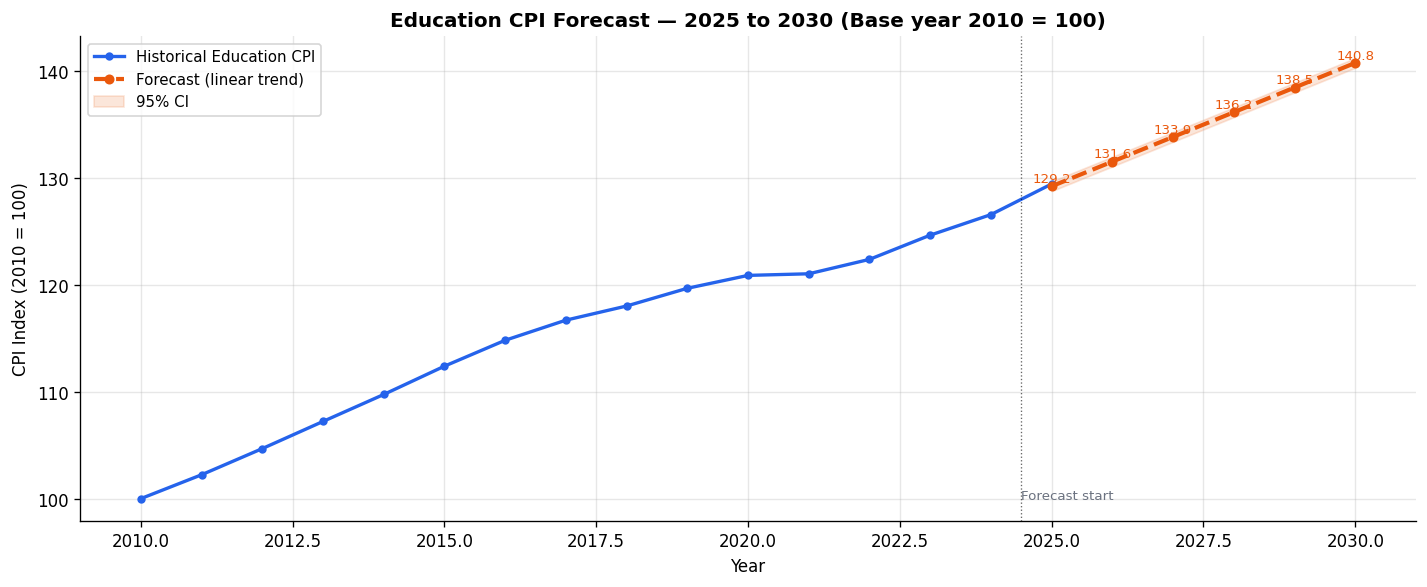

Education CPI annual growth rate (post-2022 trend): +2.31 index points/year

Forecast Education CPI:
  2025: 129.2  (implied 29.2% above 2010 base)
  2026: 131.6  (implied 31.6% above 2010 base)
  2027: 133.9  (implied 33.9% above 2010 base)
  2028: 136.2  (implied 36.2% above 2010 base)
  2029: 138.5  (implied 38.5% above 2010 base)
  2030: 140.8  (implied 40.8% above 2010 base)


In [2]:
cpi_edu = cpi[(cpi['division']=='10') & (cpi['year'] >= 2010)].copy()

# Use post-COVID trend (2022+) as baseline — more representative of current trajectory
cpi_edu_post = cpi_edu[cpi_edu['year'] >= 2022]
pred_cpi, lo_cpi, hi_cpi, slope_cpi = linear_forecast(
    cpi_edu_post['year'], cpi_edu_post['index'], FORECAST_YEARS)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(cpi_edu['year'], cpi_edu['index'],
        color=HIST_COLOR, linewidth=2, marker='o', markersize=4, label='Historical Education CPI')
ax.plot(FORECAST_YEARS, pred_cpi,
        color=FORE_COLOR, linewidth=2.5, marker='o', markersize=5,
        linestyle='--', label='Forecast (linear trend)')
ax.fill_between(FORECAST_YEARS, lo_cpi, hi_cpi, alpha=0.15, color=FORE_COLOR, label='95% CI')
ax.axvline(2024.5, color='black', linewidth=0.8, linestyle=':', alpha=0.6)
ax.annotate('Forecast start', xy=(2024.5, ax.get_ylim()[0]+2), fontsize=8, color=GRAY)

ax.set_title('Education CPI Forecast — 2025 to 2030 (Base year 2010 = 100)', fontweight='bold')
ax.set_ylabel('CPI Index (2010 = 100)')
ax.set_xlabel('Year')
ax.legend(fontsize=9)

for yr, val in zip(FORECAST_YEARS, pred_cpi):
    ax.text(yr, val + 0.4, f'{val:.1f}', ha='center', fontsize=8, color=FORE_COLOR)

plt.tight_layout()
plt.show()

print(f"Education CPI annual growth rate (post-2022 trend): +{slope_cpi:.2f} index points/year")
print(f"\nForecast Education CPI:")
for yr, val in zip(FORECAST_YEARS, pred_cpi):
    print(f"  {yr}: {val:.1f}  (implied {(val/cpi_edu[cpi_edu['year']==2010]['index'].values[0]-1)*100:.1f}% above 2010 base)")


---
## 💰 F2 — Household Income Forecast (2025–2030)

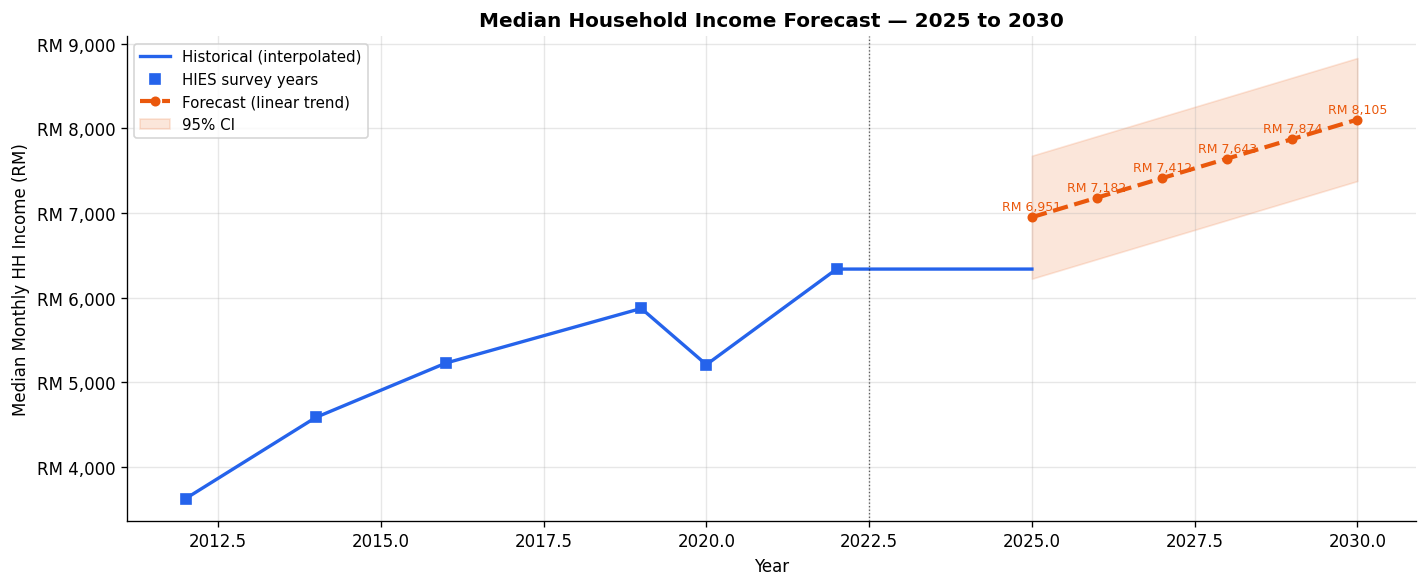

Household income annual growth: +RM 231/year

Forecast median household income:
  2025: RM 6,951/month  (RM 83,409/year)
  2026: RM 7,182/month  (RM 86,178/year)
  2027: RM 7,412/month  (RM 88,947/year)
  2028: RM 7,643/month  (RM 91,716/year)
  2029: RM 7,874/month  (RM 94,486/year)
  2030: RM 8,105/month  (RM 97,255/year)


In [3]:
# Use full HIES series for income trend
hh_years  = hh_nat['year'].values
hh_income = hh_nat['income_median'].values

pred_hh, lo_hh, hi_hh, slope_hh = linear_forecast(hh_years, hh_income, FORECAST_YEARS)

# Interpolate historical to annual for clean plot
hh_full = pd.DataFrame({'year': range(2012, 2026)})
hh_full = hh_full.merge(hh_nat[['year','income_median']], on='year', how='left')
hh_full['income_median'] = hh_full['income_median'].interpolate(method='linear')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hh_full['year'], hh_full['income_median'],
        color=HIST_COLOR, linewidth=2, label='Historical (interpolated)')
ax.plot(hh_nat['year'], hh_nat['income_median'],
        color=HIST_COLOR, linewidth=0, marker='s', markersize=6, label='HIES survey years')
ax.plot(FORECAST_YEARS, pred_hh,
        color=FORE_COLOR, linewidth=2.5, marker='o', markersize=5,
        linestyle='--', label='Forecast (linear trend)')
ax.fill_between(FORECAST_YEARS, lo_hh, hi_hh, alpha=0.15, color=FORE_COLOR, label='95% CI')
ax.axvline(2022.5, color='black', linewidth=0.8, linestyle=':', alpha=0.6)

ax.set_title('Median Household Income Forecast — 2025 to 2030', fontweight='bold')
ax.set_ylabel('Median Monthly HH Income (RM)')
ax.set_xlabel('Year')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x:,.0f}'))
ax.legend(fontsize=9)

for yr, val in zip(FORECAST_YEARS, pred_hh):
    ax.text(yr, val + 80, f'RM {val:,.0f}', ha='center', fontsize=7.5, color=FORE_COLOR)

plt.tight_layout()
plt.show()

print(f"Household income annual growth: +RM {slope_hh:.0f}/year")
print(f"\nForecast median household income:")
for yr, val in zip(FORECAST_YEARS, pred_hh):
    print(f"  {yr}: RM {val:,.0f}/month  (RM {val*12:,.0f}/year)")


---
## 💸 F3 — Affordability Index Forecast (2025–2030)

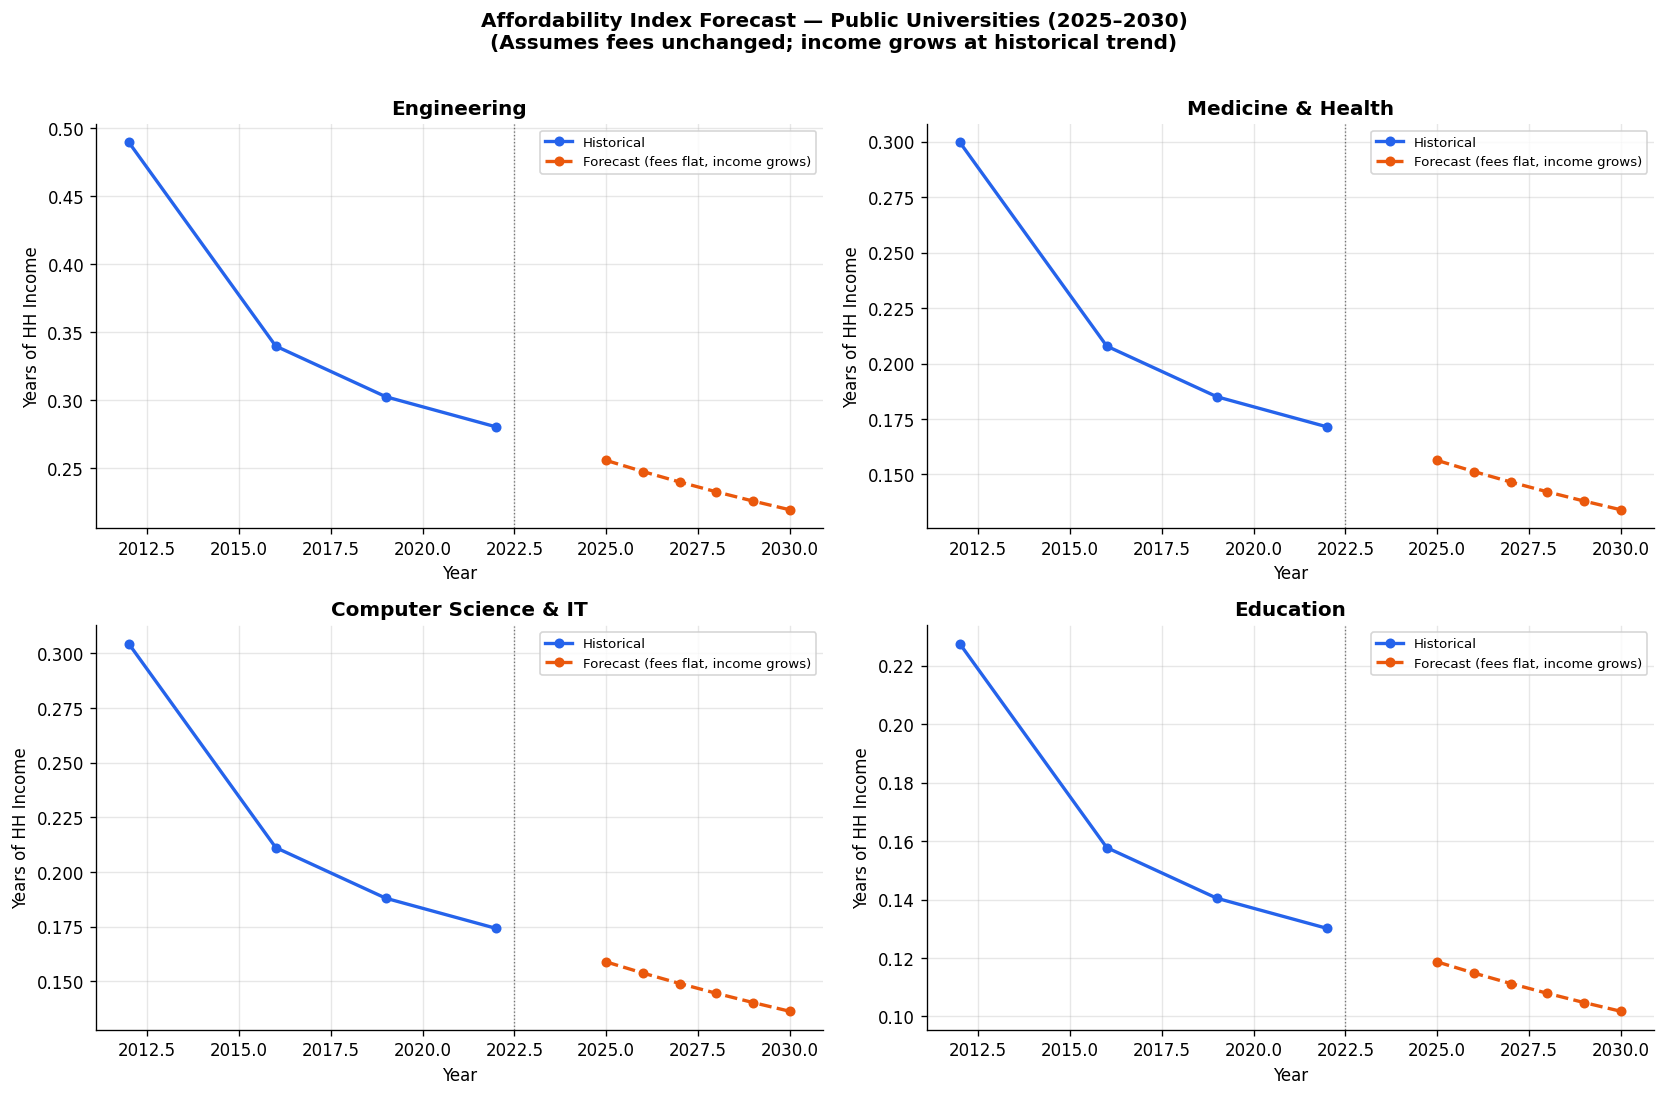

Affordability index forecast (public, 2030):
                           field  public_years
                     Engineering      0.219013
           Computer Science & IT      0.136189
               Medicine & Health      0.134081
Architecture & Built Environment      0.106139
                         Science      0.105959
                       Education      0.101760
                             Law      0.096653
            Accounting & Finance      0.093714
                 Social Sciences      0.093295
                        Business      0.092643
               Arts & Humanities      0.090574

Note: Even with fees flat, if income growth continues, degrees become MORE affordable over time.
      But if fees rise at education CPI rate, affordability will WORSEN.


In [4]:
# Affordability = current fee / (forecast annual income)
# Fees are held constant (no data on future fee increases)
# We project what affordability WOULD be if fees stayed flat and income grew

afford_forecast = []
for yr, hh_fore in zip(FORECAST_YEARS, pred_hh):
    annual_income = hh_fore * 12
    for _, row in fees.iterrows():
        if not pd.isna(row['public_avg']):
            afford_forecast.append({
                'year': yr,
                'field': row['field_category'],
                'public_years':  row['public_avg']  / annual_income,
                'private_years': row['private_avg'] / annual_income if not pd.isna(row['private_avg']) else np.nan,
            })

aff_fore_df = pd.DataFrame(afford_forecast)

# Also build historical affordability for comparison
hies_years = {
    2012: hh_nat[hh_nat['year']==2012]['income_median'].values[0],
    2016: hh_nat[hh_nat['year']==2016]['income_median'].values[0],
    2019: hh_nat[hh_nat['year']==2019]['income_median'].values[0],
    2022: hh_nat[hh_nat['year']==2022]['income_median'].values[0],
}
hist_aff = []
for yr, m_inc in hies_years.items():
    for _, row in fees.iterrows():
        if not pd.isna(row['public_avg']):
            hist_aff.append({
                'year': yr, 'field': row['field_category'],
                'public_years': row['public_avg'] / (m_inc * 12)
            })
hist_aff_df = pd.DataFrame(hist_aff)

# Plot: select 4 representative fields
fields_plot = ['Engineering', 'Medicine & Health', 'Computer Science & IT', 'Education']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, field in enumerate(fields_plot):
    hist = hist_aff_df[hist_aff_df['field']==field]
    fore = aff_fore_df[aff_fore_df['field']==field]

    axes[i].plot(hist['year'], hist['public_years'],
                 color=HIST_COLOR, marker='o', markersize=5, linewidth=2, label='Historical')
    axes[i].plot(fore['year'], fore['public_years'],
                 color=FORE_COLOR, marker='o', markersize=5, linewidth=2,
                 linestyle='--', label='Forecast (fees flat, income grows)')
    axes[i].axvline(2022.5, color='black', linewidth=0.8, linestyle=':', alpha=0.5)
    axes[i].set_title(field, fontweight='bold')
    axes[i].set_ylabel('Years of HH Income')
    axes[i].set_xlabel('Year')
    axes[i].legend(fontsize=8)

plt.suptitle('Affordability Index Forecast — Public Universities (2025–2030)\n'
             '(Assumes fees unchanged; income grows at historical trend)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Affordability index forecast (public, 2030):")
aff_2030 = aff_fore_df[aff_fore_df['year']==2030][['field','public_years']].sort_values('public_years', ascending=False)
print(aff_2030.to_string(index=False))
print("\nNote: Even with fees flat, if income growth continues, degrees become MORE affordable over time.")
print("      But if fees rise at education CPI rate, affordability will WORSEN.")


---
## 👷 F4 — Graduate Underemployment (SRU) Forecast (2025–2030)

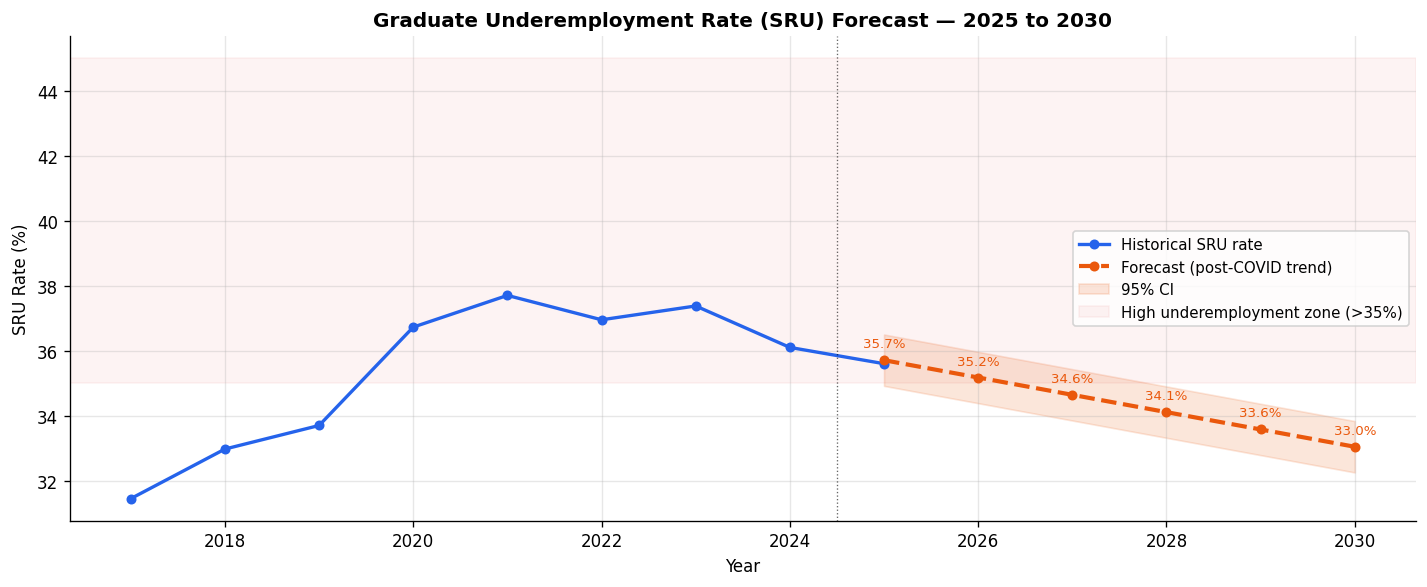

SRU post-COVID trend: -0.53 pp/year (declining)

Forecast SRU rate:
  2025: 35.7%  (95% CI: 34.9% – 36.5%)
  2026: 35.2%  (95% CI: 34.4% – 36.0%)
  2027: 34.6%  (95% CI: 33.9% – 35.4%)
  2028: 34.1%  (95% CI: 33.3% – 34.9%)
  2029: 33.6%  (95% CI: 32.8% – 34.4%)
  2030: 33.0%  (95% CI: 32.3% – 33.8%)


In [5]:
sru_overall = sru_sex[sru_sex['sex'].isin(['overall'])].groupby('year')['sru_rate'].mean()

# Use post-COVID stabilisation trend (2022+) — COVID spike should not define forecast
sru_post = sru_overall[sru_overall.index >= 2022]
pred_sru, lo_sru, hi_sru, slope_sru = linear_forecast(
    sru_post.index.tolist(), sru_post.values.tolist(), FORECAST_YEARS)

# Clip to realistic bounds
pred_sru = np.clip(pred_sru, 20, 55)
lo_sru   = np.clip(lo_sru,   15, 60)
hi_sru   = np.clip(hi_sru,   20, 65)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(sru_overall.index, sru_overall.values,
        color=HIST_COLOR, linewidth=2, marker='o', markersize=5, label='Historical SRU rate')
ax.plot(FORECAST_YEARS, pred_sru,
        color=FORE_COLOR, linewidth=2.5, marker='o', markersize=5,
        linestyle='--', label='Forecast (post-COVID trend)')
ax.fill_between(FORECAST_YEARS, lo_sru, hi_sru,
                alpha=0.15, color=FORE_COLOR, label='95% CI')
ax.axvline(2024.5, color='black', linewidth=0.8, linestyle=':', alpha=0.6)
ax.axhspan(35, 45, alpha=0.05, color=RED, label='High underemployment zone (>35%)')
ax.set_title('Graduate Underemployment Rate (SRU) Forecast — 2025 to 2030', fontweight='bold')
ax.set_ylabel('SRU Rate (%)')
ax.set_xlabel('Year')
ax.legend(fontsize=9)

for yr, val in zip(FORECAST_YEARS, pred_sru):
    ax.text(yr, val + 0.4, f'{val:.1f}%', ha='center', fontsize=8, color=FORE_COLOR)

plt.tight_layout()
plt.show()

direction = 'declining' if slope_sru < 0 else 'rising'
print(f"SRU post-COVID trend: {slope_sru:+.2f} pp/year ({direction})")
print(f"\nForecast SRU rate:")
for yr, val, lo, hi in zip(FORECAST_YEARS, pred_sru, lo_sru, hi_sru):
    print(f"  {yr}: {val:.1f}%  (95% CI: {lo:.1f}% – {hi:.1f}%)")


---
## 🔴 F5 — Combined Outlook: What Does 2030 Look Like for a 2025 Enrollee?

In [6]:
# A student enrolling in 2025 will graduate ~2028-2029
# Scenario: public university, average field
ENROL_YEAR   = 2025
GRAD_YEAR    = 2028
FORE_IDX_ENROL = FORECAST_YEARS.index(ENROL_YEAR)
FORE_IDX_GRAD  = FORECAST_YEARS.index(GRAD_YEAR)

# Projected values at graduation
hh_at_grad   = pred_hh[FORE_IDX_GRAD]
sru_at_grad  = pred_sru[FORE_IDX_GRAD]
cpi_at_grad  = pred_cpi[FORE_IDX_GRAD]

# Current (2024) baselines
hh_now    = hh_nat[hh_nat['year']==2022]['income_median'].values[0]
sru_now   = sru_overall[2024]
cpi_now   = cpi[(cpi['division']=='10')&(cpi['year']==2024)]['index'].values[0]

# Public avg fee
pub_avg_fee = fees['public_avg'].mean()
priv_avg_fee = fees['private_avg'].mean()

aff_now_pub  = pub_avg_fee  / (hh_now * 12)
aff_grad_pub = pub_avg_fee  / (hh_at_grad * 12)
aff_now_prv  = priv_avg_fee / (hh_now * 12)
aff_grad_prv = priv_avg_fee / (hh_at_grad * 12)

print("=" * 65)
print("COMBINED FORECAST: OUTLOOK FOR A 2025 ENROLLEE")
print("=" * 65)
print(f"SCENARIO: Student enrolls 2025, graduates {GRAD_YEAR}")
print()
print("COST AT ENROLMENT (2025):")
print(f"  Public avg fee:   RM {pub_avg_fee:,.0f}  ({aff_now_pub:.2f} yrs of 2022 HH income)")
print(f"  Private avg fee:  RM {priv_avg_fee:,.0f}  ({aff_now_prv:.2f} yrs of 2022 HH income)")
print(f"  Education CPI:    {cpi_now:.1f} (2010=100)")
print()
print(f"PROJECTED AT GRADUATION ({GRAD_YEAR}):")
print(f"  Median HH income:  RM {hh_at_grad:,.0f}/month  (was RM {hh_now:,} in 2022, +{(hh_at_grad/hh_now-1)*100:.1f}%)")
print(f"  Education CPI:     {cpi_at_grad:.1f}  (was {cpi_now:.1f}, +{(cpi_at_grad/cpi_now-1)*100:.1f}%)")
print(f"  SRU rate:          {sru_at_grad:.1f}%  (was {sru_now:.1f}% in 2024)")
print()
print("AFFORDABILITY CHANGE:")
pub_dir  = 'improves' if aff_grad_pub < aff_now_pub else 'worsens'
priv_dir = 'improves' if aff_grad_prv < aff_now_prv else 'worsens'
print(f"  Public degree:   {aff_now_pub:.2f} yrs -> {aff_grad_pub:.2f} yrs  ({pub_dir})")
print(f"  Private degree:  {aff_now_prv:.2f} yrs -> {aff_grad_prv:.2f} yrs  ({priv_dir})")
print()
print("UNDEREMPLOYMENT RISK AT GRADUATION:")
print(f"  {sru_at_grad:.1f}% chance of landing in a job that does not require the degree.")
print(f"  1 in {100/sru_at_grad:.0f} graduates will be underemployed at point of entry.")
print()
sru_dir = 'continues declining' if slope_sru < 0 else 'remains elevated'
print("VERDICT:")
print("  If current trends hold, a 2025 enrollee graduates into a market where:")
print("  - Public degrees become slightly more affordable (income grows faster than fees)")
print(f"  - Private degrees remain a {aff_grad_prv:.1f}-year income commitment -- extreme burden")
print(f"  - Underemployment {sru_dir} at ~{sru_at_grad:.0f}%")
print("  - The structural mismatch between degree supply and skilled jobs persists")
print("=" * 65)


COMBINED FORECAST: OUTLOOK FOR A 2025 ENROLLEE
SCENARIO: Student enrolls 2025, graduates 2028

COST AT ENROLMENT (2025):
  Public avg fee:   RM 11,229  (0.15 yrs of 2022 HH income)
  Private avg fee:  RM 125,198  (1.65 yrs of 2022 HH income)
  Education CPI:    126.6 (2010=100)

PROJECTED AT GRADUATION (2028):
  Median HH income:  RM 7,643/month  (was RM 6,338 in 2022, +20.6%)
  Education CPI:     136.2  (was 126.6, +7.6%)
  SRU rate:          34.1%  (was 36.1% in 2024)

AFFORDABILITY CHANGE:
  Public degree:   0.15 yrs -> 0.12 yrs  (improves)
  Private degree:  1.65 yrs -> 1.37 yrs  (improves)

UNDEREMPLOYMENT RISK AT GRADUATION:
  34.1% chance of landing in a job that does not require the degree.
  1 in 3 graduates will be underemployed at point of entry.

VERDICT:
  If current trends hold, a 2025 enrollee graduates into a market where:
  - Public degrees become slightly more affordable (income grows faster than fees)
  - Private degrees remain a 1.4-year income commitment -- extreme

---
## 📊 F6 — Scenario Comparison Chart

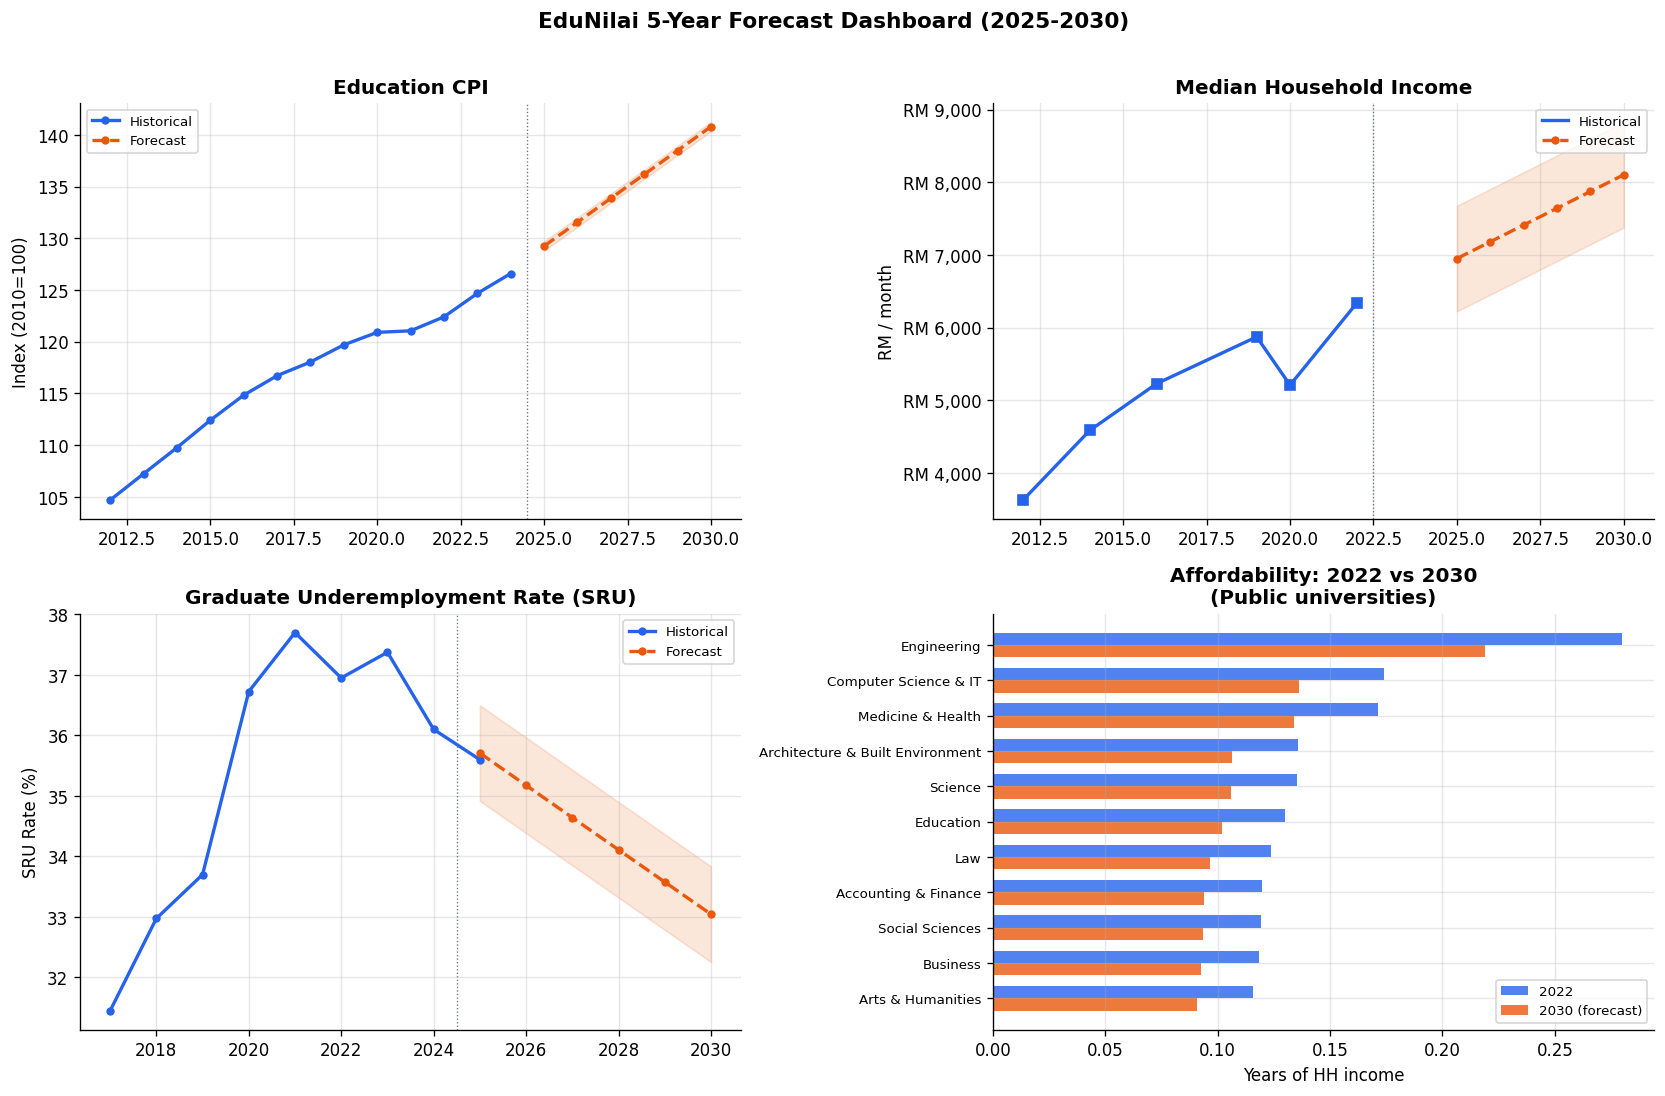

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

all_years_hist = list(range(2012, 2025))
all_years_fore = FORECAST_YEARS

# ── Panel 1: Education CPI ─────────────────────────────────────────
cpi_hist = cpi[(cpi['division']=='10')&(cpi['year'].between(2012,2024))].set_index('year')['index']
axes[0].plot(cpi_hist.index, cpi_hist.values, color=HIST_COLOR, linewidth=2, marker='o', markersize=4, label='Historical')
axes[0].plot(FORECAST_YEARS, pred_cpi, color=FORE_COLOR, linewidth=2, marker='o', markersize=4, linestyle='--', label='Forecast')
axes[0].fill_between(FORECAST_YEARS, lo_cpi, hi_cpi, alpha=0.15, color=FORE_COLOR)
axes[0].axvline(2024.5, color=GRAY, linewidth=0.8, linestyle=':')
axes[0].set_title('Education CPI', fontweight='bold')
axes[0].set_ylabel('Index (2010=100)')
axes[0].legend(fontsize=8)

# ── Panel 2: Household income ──────────────────────────────────────
axes[1].plot(hh_full[hh_full['year']<=2022]['year'], hh_full[hh_full['year']<=2022]['income_median'],
             color=HIST_COLOR, linewidth=2, label='Historical')
axes[1].plot(hh_nat['year'], hh_nat['income_median'], color=HIST_COLOR, marker='s', markersize=6, linewidth=0)
axes[1].plot(FORECAST_YEARS, pred_hh, color=FORE_COLOR, linewidth=2, marker='o', markersize=4, linestyle='--', label='Forecast')
axes[1].fill_between(FORECAST_YEARS, lo_hh, hi_hh, alpha=0.15, color=FORE_COLOR)
axes[1].axvline(2022.5, color=GRAY, linewidth=0.8, linestyle=':')
axes[1].set_title('Median Household Income', fontweight='bold')
axes[1].set_ylabel('RM / month')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x:,.0f}'))
axes[1].legend(fontsize=8)

# ── Panel 3: SRU rate ──────────────────────────────────────────────
axes[2].plot(sru_overall.index, sru_overall.values, color=HIST_COLOR, linewidth=2, marker='o', markersize=4, label='Historical')
axes[2].plot(FORECAST_YEARS, pred_sru, color=FORE_COLOR, linewidth=2, marker='o', markersize=4, linestyle='--', label='Forecast')
axes[2].fill_between(FORECAST_YEARS, lo_sru, hi_sru, alpha=0.15, color=FORE_COLOR)
axes[2].axvline(2024.5, color=GRAY, linewidth=0.8, linestyle=':')
axes[2].set_title('Graduate Underemployment Rate (SRU)', fontweight='bold')
axes[2].set_ylabel('SRU Rate (%)')
axes[2].legend(fontsize=8)

# ── Panel 4: Affordability by field (2022 vs 2030) ─────────────────
aff_2022 = hist_aff_df[hist_aff_df['year']==2022].set_index('field')['public_years']
aff_2030 = aff_fore_df[aff_fore_df['year']==2030].set_index('field')['public_years']
common   = aff_2022.index.intersection(aff_2030.index)
df_cmp   = pd.DataFrame({'2022': aff_2022[common], '2030': aff_2030[common]}).sort_values('2022', ascending=True)

x = np.arange(len(df_cmp))
w = 0.35
axes[3].barh(x + w/2, df_cmp['2022'], w, color=HIST_COLOR, alpha=0.8, label='2022')
axes[3].barh(x - w/2, df_cmp['2030'], w, color=FORE_COLOR, alpha=0.8, label='2030 (forecast)')
axes[3].set_yticks(x)
axes[3].set_yticklabels(df_cmp.index, fontsize=8)
axes[3].set_xlabel('Years of HH income')
axes[3].set_title('Affordability: 2022 vs 2030\n(Public universities)', fontweight='bold')
axes[3].legend(fontsize=8)
axes[3].axvline(0, color='black', linewidth=0.5)

plt.suptitle('EduNilai 5-Year Forecast Dashboard (2025-2030)', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## 💾 Save Forecast Outputs

In [ ]:
os.makedirs('../data/analysis', exist_ok=True)

# CPI forecast
pd.DataFrame({'year': FORECAST_YEARS, 'cpi_edu_forecast': pred_cpi,
              'cpi_lo': lo_cpi, 'cpi_hi': hi_cpi})  .to_csv('../data/analysis/forecast_cpi.csv', index=False)

# HH income forecast
pd.DataFrame({'year': FORECAST_YEARS, 'income_median_forecast': pred_hh,
              'income_lo': lo_hh, 'income_hi': hi_hh})  .to_csv('../data/analysis/forecast_hh_income.csv', index=False)

# SRU forecast
pd.DataFrame({'year': FORECAST_YEARS, 'sru_forecast': pred_sru,
              'sru_lo': lo_sru, 'sru_hi': hi_sru})  .to_csv('../data/analysis/forecast_sru.csv', index=False)

# Affordability forecast
aff_fore_df.to_csv('../data/analysis/forecast_affordability.csv', index=False)

print("Saved all forecast CSVs to ../data/analysis/")
print("  forecast_cpi.csv")
print("  forecast_hh_income.csv")
print("  forecast_sru.csv")
print("  forecast_affordability.csv")
